In [343]:
import h5py as h5 
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
plt.style.use('../../utils/dune.mplstyle')

import sys, os

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker # Now this works

In [344]:
def ticks_to_time(hits_time,tick_time=0.1):
    '''Returns the time in microseconds'''
    return hits_time*tick_time 

In [345]:
test_file = "/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_tests/2x2_AmBe_in_mod2_prompt_window_MOD.FLOW.hdf5"

In [346]:
file = h5.File(test_file, "r")
print(file.keys())

<KeysViewHDF5 ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']>


In [347]:
traj = file["mc_truth/trajectories/data"]
seg = file["mc_truth/segments/data"]

In [348]:
np.unique(traj['event_id'])

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=uint32)

In [349]:
event_id = 2

In [350]:
ev_traj= traj[traj['event_id']==event_id]
ev_seg= seg[seg['event_id']==event_id]

In [351]:
print(ev_seg['pdg_id'])

[1000180410         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11         11         11
         11         11         11         11 1000180400]


In [352]:
entry = event_id-1
prompt_hits_backtrack, prompt_hits = get_charge_event_hits(entry,file)
new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)


In [353]:
new_hits['best_segment_id']

array([2184,   -1,   -1, 2189, 2196, 2198, 2201, 2201, 2199, 2198, 2202],
      dtype=int32)

In [354]:
new_hits['neutron_process']

array([1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [355]:
new_hits['parent_neutron_id']

array([ 0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)

In [356]:
total = 0
for seg in ev_seg:
    if(seg['segment_id'] in new_hits[new_hits['neutron_process']==1]['best_segment_id']):
        total+=seg['dE']
    else:
        continue
print(total)

4.356174573302269


In [357]:
print(np.sum(new_hits[new_hits['neutron_process']==1]['E']))

4.925969000697127


In [358]:
hits_x = new_hits['x']
hits_y = new_hits['y']
hits_z = new_hits['z']
hits_t = ticks_to_time(new_hits['ts_pps'])
hits_c = new_hits['neutron_process']


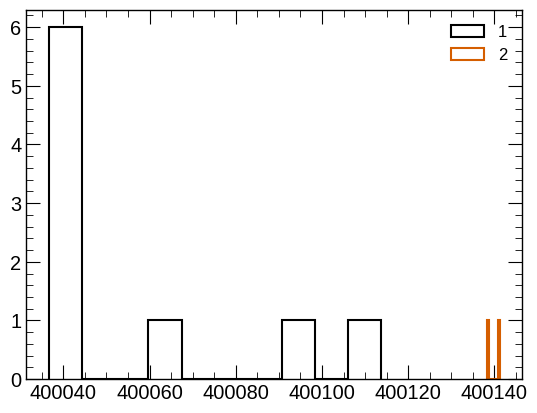

In [359]:
for pr in np.unique(new_hits['neutron_process']):
    label_pr = pr
    plt.hist(ticks_to_time(new_hits[new_hits['neutron_process']==pr]['ts_pps']),histtype='step',label=label_pr)
plt.legend()
plt.show()

In [360]:
# --------------------------------------------------
# Cube dimensions
# --------------------------------------------------
Lmin, Lmax = -70, 70

# --------------------------------------------------
# Create event display
# --------------------------------------------------
fig = go.Figure()

# --- Add hit points colored by time ---
fig.add_trace(go.Scatter3d(
    x=hits_x, y=hits_y, z=hits_z,
    mode='markers',
    marker=dict(
        size=4,
        color=hits_c,             # <-- color by time
        colorscale='Turbo',      # 'Viridis', 'Plasma', 'Turbo', etc.
        colorbar=dict(title="Time"),
        opacity=0.9
    ),
    name="Hits"
))

# --------------------------------------------------
# Add detector cube edges
# --------------------------------------------------
cube_edges = [
    # bottom
    [(Lmin,Lmin,Lmin), (Lmax,Lmin,Lmin)],
    [(Lmax,Lmin,Lmin), (Lmax,Lmax,Lmin)],
    [(Lmax,Lmax,Lmin), (Lmin,Lmax,Lmin)],
    [(Lmin,Lmax,Lmin), (Lmin,Lmin,Lmin)],

    # top
    [(Lmin,Lmin,Lmax), (Lmax,Lmin,Lmax)],
    [(Lmax,Lmin,Lmax), (Lmax,Lmax,Lmax)],
    [(Lmax,Lmax,Lmax), (Lmin,Lmax,Lmax)],
    [(Lmin,Lmax,Lmax), (Lmin,Lmin,Lmax)],

    # verticals
    [(Lmin,Lmin,Lmin), (Lmin,Lmin,Lmax)],
    [(Lmax,Lmin,Lmin), (Lmax,Lmin,Lmax)],
    [(Lmax,Lmax,Lmin), (Lmax,Lmax,Lmax)],
    [(Lmin,Lmax,Lmin), (Lmin,Lmax,Lmax)],
]

for (x0,y0,z0),(x1,y1,z1) in cube_edges:
    fig.add_trace(go.Scatter3d(
        x=[x0,x1],
        y=[y0,y1],
        z=[z0,z1],
        mode='lines',
        line=dict(color='black', width=4),
        showlegend=False
    ))

# --------------------------------------------------
# Layout
# --------------------------------------------------
fig.update_layout(
    scene=dict(
        xaxis=dict(title='x [cm]', range=[Lmin, Lmax]),
        yaxis=dict(title='y [cm]', range=[Lmin, Lmax]),
        zaxis=dict(title='z [cm]', range=[Lmin, Lmax]),
        aspectmode='cube'
    ),
    width=800,
    height=800,
    title="3D Event Display Colored by Time"
)

fig.show()
